## Why Did They Cancel? A Guide to Causal Inference with Observational Data

A correlation is observed in the hotel's data: customers who are assigned a different room from the one they originally booked appear to cancel more often. The obvious business decision seems to be to stop reassigning rooms. But is this correlation actually causation? What if the customers who get different rooms are also the ones who book last-minute or during peak season? This is the classic challenge of **confounding**, where a hidden variable influences both the treatment and the outcome, making simple analysis misleading.

This tutorial tackles a fundamental causal question using only historical, or **observational**, data: **How can we determine the true causes of an outcome when we could not run a perfect experiment?** We will use a four-step causal inference framework—Model, Identify, Estimate, and Refute—to uncover the real reason behind hotel booking cancellations.

In this task, we will apply **Python** and the [**DoWhy**](https://github.com/py-why/dowhy) library to learn structured causal reasoning through the following steps:
  * How to use **observational data** to answer causal questions when experiments are not feasible.
  * The four key steps of causal inference: **Model, Identify, Estimate, and Refute**.
  * How to create a **causal graph** to make your assumptions explicit.
  * How to use `DoWhy` to estimate the **Average Treatment Effect (ATE)**.
  * How to **refute** your findings to build confidence in your causal conclusion.

**Credits**

This tutorial uses the hotel bookings dataset from [Antonio, Almeida, and Nunes (2019)](https://www.sciencedirect.com/science/article/pii/S2352340918315191#f0010), which is publicly available on GitHub from the [rfordatascience/tidytuesday](https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-02-11) repository.

**Compatibility**

This tutorial uses standard data science libraries and is compatible with most Python environments.

| Platform                     | Compatible | Recommended | Notes                                                               |
| :--------------------------- | :--------: | :---------: | :------------------------------------------------------------------ |
| **Local (e.g., MacBook/PC)** |   ✅ Yes   |    ✅ Yes   | Perfect for learning. The dataset is small and runs instantly.      |
| **Google Colab** |   ✅ Yes   |    ✅ Yes   | An excellent option. Requires installing DoWhy: `pip install dowhy`. |
| **Midway/HPC Clusters** |   ✅ Yes   |    ✅ Yes   | Works well. Requires installing DoWhy: `pip install dowhy`.       |



### Setting Up the Task: The Hotel Bookings Problem

Our goal is to understand the causal factors behind booking cancellations. A randomized experiment is off the table—it would be costly and unethical to deliberately provide poor service. Therefore, we must rely on observational data and causal inference techniques to find the answer.

#### **Imports and Data Loading**

First, let's import the necessary libraries and load the dataset.

In [ ]:
# On Colab, run this to install graphviz system library
# On Midway, make sure you have loaded graphviz module using `module load graphviz`
# On other systems, follow https://pygraphviz.github.io/documentation/stable/install.html
!apt install libgraphviz-dev

In [ ]:
# Now install the graphviz Python bindings
%pip install dowhy pygraphviz

      Successfully uninstalled cvxpy-1.6.7


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dowhy

In [ ]:
# Run this on Colab to retrieve the dataset
!wget https://github.com/rfordatascience/tidytuesday/raw/refs/heads/main/data/2020/2020-02-11/hotels.csv
!mkdir hotel_bookings
!mv hotels.csv hotel_bookings/hotel_bookings.csv

In [ ]:
dataset = pd.read_csv('hotel_bookings/hotel_bookings.csv')
dataset.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


#### **Data Cleaning and Feature Engineering**

Real-world data is messy. We'll perform some feature engineering to create more meaningful variables and clean the dataset by dropping irrelevant columns and handling missing values.

In [ ]:
# Total stay in nights
dataset['total_stay'] = dataset['stays_in_week_nights'] + dataset['stays_in_weekend_nights']
# Total number of guests
dataset['guests'] = dataset['adults'] + dataset['children'] + dataset['babies']
# Creating the different_room_assigned feature
dataset['different_room_assigned'] = 0
slice_indices = dataset['reserved_room_type'] != dataset['assigned_room_type']
dataset.loc[slice_indices, 'different_room_assigned'] = 1

# Deleting older features
dataset = dataset.drop(['stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'children', 'babies',
                        'reserved_room_type', 'assigned_room_type'], axis=1)

# Drop columns with many missing values or that are irrelevant for this analysis
dataset = dataset.drop(['agent', 'company', 'reservation_status', 'reservation_status_date',
                        'arrival_date_day_of_month', 'arrival_date_year', 'distribution_channel'], axis=1)

# Impute missing country with the mode
dataset['country'] = dataset['country'].fillna(dataset['country'].mode()[0])

# Convert binary columns to boolean for clarity
dataset['different_room_assigned'] = dataset['different_room_assigned'].replace({1: True, 0: False})
dataset['is_canceled'] = dataset['is_canceled'].replace({1: True, 0: False})
dataset.dropna(inplace=True)

# For this analysis, we'll focus on the most common scenario: bookings with no deposit
dataset = dataset[dataset.deposit_type == "No Deposit"]
dataset

/tmp/ipython-input-2223927889.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['different_room_assigned'] = dataset['different_room_assigned'].replace({1: True, 0: False})
/tmp/ipython-input-2223927889.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['is_canceled'] = dataset['is_canceled'].replace({1: True, 0: False})


,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,meal,country,market_segment,is_repeated_guest,previous_cancellations,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay,guests,different_room_assigned
0,Resort Hotel,False,342,July,27,BB,PRT,Direct,0,0,...,3,No Deposit,0,Transient,0.00,0,0,0,2.0,False
1,Resort Hotel,False,737,July,27,BB,PRT,Direct,0,0,...,4,No Deposit,0,Transient,0.00,0,0,0,2.0,False
2,Resort Hotel,False,7,July,27,BB,GBR,Direct,0,0,...,0,No Deposit,0,Transient,75.00,0,0,1,1.0,True
3,Resort Hotel,False,13,July,27,BB,GBR,Corporate,0,0,...,0,No Deposit,0,Transient,75.00,0,0,1,1.0,False
4,Resort Hotel,False,14,July,27,BB,GBR,Online TA,0,0,...,0,No Deposit,0,Transient,98.00,0,1,2,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,False,23,August,35,BB,BEL,Offline TA/TO,0,0,...,0,No Deposit,0,Transient,96.14,0,0,7,2.0,False
119386,City Hotel,False,102,August,35,BB,FRA,Online TA,0,0,...,0,No Deposit,0,Transient,225.43,0,2,7,3.0,False
119387,City Hotel,False,34,August,35,BB,DEU,Online TA,0,0,...,0,No Deposit,0,Transient,157.71,0,4,7,2.0,False
119388,City Hotel,False,109,August,35,BB,GBR,Online TA,0,0,...,0,No Deposit,0,Transient,104.40,0,0,7,2.0,False


After cleaning, we have a dataset ready for causal analysis, where our **treatment** is `different_room_assigned` and our **outcome** is `is_canceled`.


### Step 1: Model - Stating Your Assumptions with a Causal Graph

One of the most important steps in causal inference is to clearly describe the assumptions. We do this by creating a **causal graph**, which is a visual representation of how we believe the variables in the system influence each other. Our key assumptions include:

  * `market_segment` (e.g., Travel Agent vs. Direct) affects `lead_time`.
  * `lead_time` affects whether a booking is `is_canceled`.
  * `booking_changes` can affect both whether a `different_room_assigned` is given and whether the booking `is_canceled`.
  * There might be **Unobserved Confounders** (U) that we haven't measured but that could affect multiple variables.

<!-- end list -->

/usr/local/lib/python3.12/dist-packages/dowhy/causal_model.py:581: UserWarning: 1 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


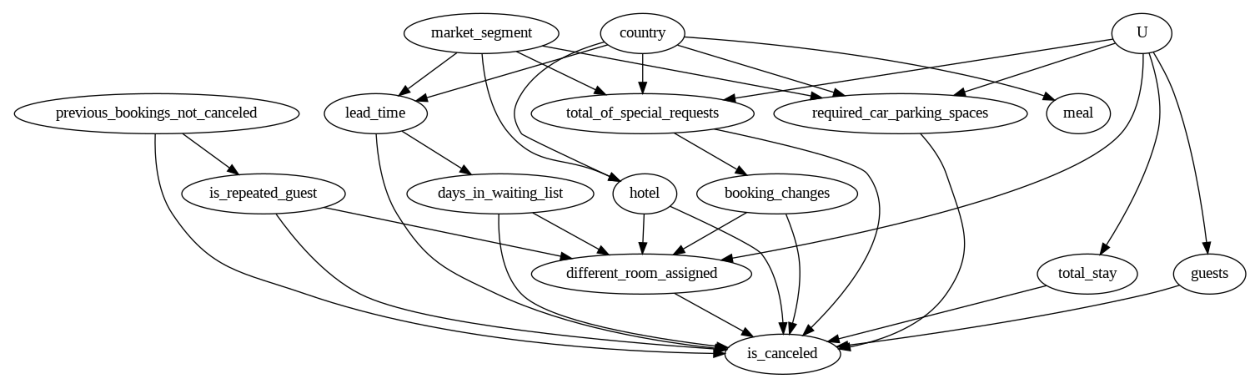

In [ ]:
import pygraphviz
causal_graph = """
digraph {
    different_room_assigned[label="Different Room Assigned"];
    is_canceled[label="Booking Cancelled"];
    booking_changes[label="Booking Changes"];
    previous_bookings_not_canceled[label="Previous Booking Retentions"];
    days_in_waiting_list[label="Days in Waitlist"];
    lead_time[label="Lead Time"];
    market_segment[label="Market Segment"];
    country[label="Country"];
    U[label="Unobserved Confounders", observed="no"];
    is_repeated_guest;
    total_stay;
    guests;
    meal;
    hotel;

    U->{different_room_assigned,required_car_parking_spaces,guests,total_stay,total_of_special_requests};
    market_segment -> lead_time;
    lead_time->is_canceled;
    country -> lead_time;
    different_room_assigned -> is_canceled;
    country->meal;
    lead_time -> days_in_waiting_list;
    days_in_waiting_list ->{is_canceled,different_room_assigned};
    previous_bookings_not_canceled -> is_canceled;
    previous_bookings_not_canceled -> is_repeated_guest;
    is_repeated_guest -> {different_room_assigned,is_canceled};
    total_stay -> is_canceled;
    guests -> is_canceled;
    booking_changes -> different_room_assigned;
    booking_changes -> is_canceled;
    hotel -> {different_room_assigned,is_canceled};
    required_car_parking_spaces -> is_canceled;
    total_of_special_requests -> {booking_changes,is_canceled};
    country->{hotel, required_car_parking_spaces,total_of_special_requests};
    market_segment->{hotel, required_car_parking_spaces,total_of_special_requests};
}
"""

# Create the CausalModel
model = dowhy.CausalModel(
    data=dataset,
    graph=causal_graph.replace("\n", " "),
    treatment="different_room_assigned",
    outcome='is_canceled'
)

model.view_model(size=(16, 12))

### Step 2: Identify - Finding a Path to the Cause

Based on the graph, `DoWhy`'s `identify_effect` method determines *how* the causal effect can be calculated. It finds a statistically valid method to isolate the effect of the treatment on the outcome, controlling for the appropriate confounders.

In [ ]:
# Identify the causal effect
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
──────────────────────────(E[is_canceled|total_stay,total_of_special_requests, ↪
d[different_room_assigned]                                                     ↪

↪                                                                              ↪
↪ required_car_parking_spaces,guests,lead_time,hotel,booking_changes,is_repeat ↪
↪                                                                              ↪

↪                                
↪ ed_guest,days_in_waiting_list])
↪                                
Estimand assumption 1, Unconfoundedness: If U→{different_room_assigned} and U→is_canceled then P(is_canceled|different_room_assigned,total_stay,total_of_special_requests,required_car_parking_spaces,guests,lead_time,hotel,booking_changes,is_repeated_guest,days_in_waiting_list,U) = P(is_canceled|differ

**Analysis:** The output shows that `DoWhy` has identified a **backdoor** estimand. This means it's possible to estimate the causal effect by adjusting for a specific set of confounding variables that block the "backdoor paths" between our treatment and outcome.

### Step 3: Estimate - Calculating the Causal Effect

Now we can finally calculate the number. We use the identified estimand and choose an estimation method, like `propensity_score_weighting`. The result is the **Average Treatment Effect (ATE)**.

In [ ]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate"
)

print(estimate)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
──────────────────────────(E[is_canceled|total_stay,total_of_special_requests, ↪
d[different_room_assigned]                                                     ↪

↪                                                                              ↪
↪ required_car_parking_spaces,guests,lead_time,hotel,booking_changes,is_repeat ↪
↪                                                                              ↪

↪                                
↪ ed_guest,days_in_waiting_list])
↪                                
Estimand assumption 1, Unconfoundedness: If U→{different_room_assigned} and U→is_canceled then P(is_canceled|different_room_assigned,total_stay,total_of_special_requests,required_car_parking_spaces,guests,lead_time,hotel,booking_changes,is_repeated_gues

**Analysis:** The causal estimate is **-0.26**. This is a surprising and counter-intuitive result\! It suggests that being assigned a different room **decreases** the probability of cancellation by 26%. This is the opposite of what a simple correlation might suggest.

**Why could this be?** Perhaps a different room is only assigned when the customer is already at the hotel and the original room is unavailable. At that point, the customer is far less likely to cancel. This highlights a critical point: our causal graph might be missing key variables (like *when* the room change happens), and the estimate is only as good as our initial assumptions.

### Step 4: Refute - Stress-Testing Your Assumptions

A causal estimate is not complete until it has been tested. `DoWhy` includes powerful **refutation** methods to check the robustness of our result.

1.  **Random Common Cause:** Adds a random variable that acts as a common cause. A robust estimate should not change significantly.
2.  **Placebo Treatment:** Replaces the real treatment with a random variable (a placebo). The causal effect should drop to zero.
3.  **Data Subset Refuter:** Splits the data into random subsets. The estimate should remain stable across all subsets.

<!-- end list -->

In [ ]:
# Refutation 1: Random Common Cause
refute1_results = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print(refute1_results)

# Refutation 2: Placebo Treatment
refute2_results = model.refute_estimate(identified_estimand, estimate, method_name="placebo_treatment_refuter")
print(refute2_results)

# Refutation 3: Data Subset
refute3_results = model.refute_estimate(identified_estimand, estimate, method_name="data_subset_refuter")
print(refute3_results)

Refute: Add a random common cause
Estimated effect:-0.2620530661034368
New effect:-0.2620530661034368
p value:1.0

Refute: Use a Placebo Treatment
Estimated effect:-0.2620530661034368
New effect:0.055523854202537824
p value:0.0

Refute: Use a subset of data
Estimated effect:-0.2620530661034368
New effect:-0.26215755754550796
p value:0.98



**Analysis:** Our estimate holds up well against all three tests. The effect remains stable when adding a random common cause and when using data subsets, and it correctly drops to near-zero with a placebo treatment. While this doesn't *prove* our result is correct, it significantly increases our confidence in the estimate, given our initial assumptions.

### Conclusion

In this tutorial, we went beyond simple correlations to ask a causal question using only observational data. By following the four steps of causal inference with `DoWhy`, we were able to:

  * **Make our assumptions explicit** using a causal graph.
  * **Identify and estimate** a robust causal effect.
  * **Uncover a counter-intuitive insight:** that assigning a different room may actually *prevent* cancellations, prompting a deeper investigation into the hotel's processes.
  * **Validate our findings** using powerful refutation methods.

This structured approach prevents us from jumping to incorrect conclusions based on misleading correlations and provides a powerful framework for making data-driven decisions in any domain.